# Active Perception Workshop

In this tutorial we will implement a basic perception-action loop to drive intelligent and adaptive focused transmit steering. We will use [Diffusion Models](http://127.0.0.1:8000/_autosummary/zea.models.diffusion.html#zea.models.diffusion.DiffusionModel) to implement perception-as-inference, with [greedy entropy minimization](http://127.0.0.1:8000/_autosummary/zea.agent.selection.html#zea.agent.selection.GreedyEntropy) as our action selection policy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/agent/agent_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/agent/agent_example.ipynb)
&nbsp;
[![Hugging Face model](https://img.shields.io/badge/Hugging%20Face-Model-yellow?logo=huggingface)](https://huggingface.co/zeahub/diffusion-echonet-dynamic)

In [ ]:
%%capture
%pip install zea
%pip install tabulate

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [ ]:
import keras
import keras.ops as ops
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from tqdm import tqdm

from zea import init_device
from zea.models.diffusion import DiffusionModel
from zea.ops import Pipeline, ScanConvert
from zea.data import Dataset
from zea.visualize import plot_image_grid, set_mpl_style
from zea.agent.selection import GreedyEntropy
from zea.utils import translate
from zea.backend import jit
from zea.backend.tensorflow.dataloader import make_dataloader

In [ ]:
n_prior_samples = 4
n_unconditional_steps = 90
n_initial_conditonal_steps = 180
n_conditional_steps = 200
n_conditional_samples = 4

We will work with the GPU if available, and initialize using `init_device` to pick the best available device. Also, (optionally), we will set the matplotlib style for plotting.

In [ ]:
init_device(verbose=False)
set_mpl_style()

nvidia-smi is not available. Please install nvidia-utils. Cannot retrieve GPU memory. Falling back to CPU..


## Load dataset and model

In [ ]:
# load generative model
model = DiffusionModel.from_preset("diffusion-echonet-dynamic")
img_shape = model.input_shape[:2]


# load camus dataset
dataset = Dataset(["hf://zeahub/camus-sample/val", "hf://zeahub/camus-sample/train"], key="image")
def preprocess(sample):
  sample = sample["data"]["image"]
  sample = keras.ops.expand_dims(sample, axis=-1)
  sample = keras.ops.image.resize(sample, img_shape)
  dynamic_range = (-40, 0)
  sample = keras.ops.clip(sample, dynamic_range[0], dynamic_range[1])
  sample = translate(sample, dynamic_range, (-1, 1))
  sample = sample[..., 0]  # remove channel dim
  return sample


data = preprocess(dataset[0])

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/858 [00:00<?, ?B/s]

model.weights.h5:   0%|          | 0.00/31.7M [00:00<?, ?B/s]

val/patient0401/patient0401_2CH_half_seq(…):   0%|          | 0.00/44.5M [00:00<?, ?B/s]

val/patient0401/patient0401_4CH_half_seq(…):   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Checking dataset files on validity (zea format): 100%|██████████| 2/2 [00:00<00:00, 187.54it/s]


train/patient0101/patient0101_2CH_half_s(…):   0%|          | 0.00/62.9M [00:00<?, ?B/s]

train/patient0101/patient0101_4CH_half_s(…):   0%|          | 0.00/46.3M [00:00<?, ?B/s]

Checking dataset files on validity (zea format): 100%|██████████| 2/2 [00:00<00:00, 216.51it/s]


## Visualize target sequence
Here we load a sequence of ultrasound frames from the CAMUS validation set. This will be our 'ground truth' target sequence, that the agent will need to reconstruct from a small budget of focused scan lines

GPU support for order > 1 is not available. Disabling jit for ScanConvert.


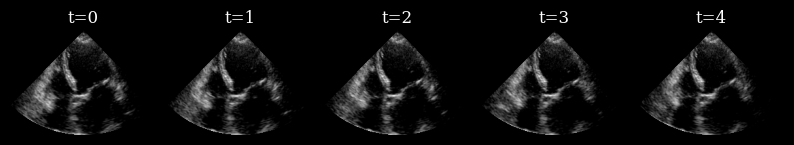

In [ ]:
scan_convert = Pipeline([ScanConvert(order=2, jit_compile=False)])
parameters = {
    "theta_range": [-0.78, 0.78],  # [-45, 45] in radians
    "rho_range": [0, 1],
}
parameters = scan_convert.prepare_parameters(**parameters)
data_sc = scan_convert(data=data, **parameters)["data"]

n_frames_to_plot = 5
fig, _ = plot_image_grid(
    data_sc[:n_frames_to_plot],
    titles=[f"t={t}" for t in range(n_frames_to_plot)],
    ncols=n_frames_to_plot,
    remove_axis=True,
    vmin=-1,
    vmax=1,
)

## Simulate Focused Line Acquisition
We use a simple masking operator to simulate acquiring a set of focused lines from the tissue, where each line reveals a vertical column of pixels, in the polar domain, of the target.

In [ ]:
def simulate_acquisition(full_frame, mask):
    measurement = full_frame[None, ...] * mask
    return measurement, mask

### Sampling from the prior

Initially, we have not yet acquired any measurements, so we draw samples from the prior to drive our actions.

90/90 ━━━━━━━━━━━━━━━━━━━━ 80s 834ms/step


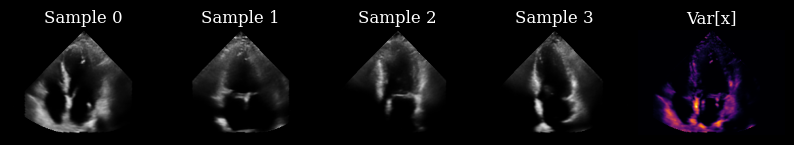

In [ ]:
prior_samples = model.sample(n_samples=n_prior_samples, n_steps=n_unconditional_steps, verbose=True)
scan_converted_prior_samples = scan_convert(
    data=keras.ops.squeeze(prior_samples, axis=-1), **parameters
)["data"]
posterior_variance = ops.nan_to_num(ops.var(scan_converted_prior_samples, axis=0))
fig, _ = plot_image_grid(
    list(scan_converted_prior_samples) + [translate(posterior_variance, range_to=(-1, 1))],
    titles=[f"Sample {i}" for i in range(n_prior_samples)] + ["Var[x]"],
    vmin=-1,
    vmax=1,
    cmap=["gray"] * n_prior_samples + ["inferno"],
)

Next, we implement a perception-action loop, using a greedy entropy minimization strategy to select which lines to acquire next in the sequence. Each set of generated posterior samples at time $t$ are used as _initial samples_ for the reverse diffusion at time $t+1$ [1], ensuring that we generate a reconstructed sequence that is coherent over time.

[1] https://ieeexplore.ieee.org/document/10889752

### Posterior sampling

In [ ]:
from zea.agent import masks, selection

frame_height, frame_width, _ = model.input_shape
random_line_selector = selection.UniformRandomLines(
    n_actions=14,
    n_possible_actions=frame_width,
    img_width=frame_width,
    img_height=frame_height,
)
selected_lines, measurement_mask = random_line_selector.sample(batch_size=1)
target_frame = data[0]
measurements, measurement_mask = simulate_acquisition(target_frame, measurement_mask)
posterior_samples = model.posterior_sample(
    measurements=measurements[..., None],  # add channel dim
    mask=measurement_mask[..., None],  # add channel dim
    initial_samples=None,
    n_samples=n_conditional_samples,
    n_steps=n_conditional_steps,
    omega=10,
    initial_step=0,
)

In [ ]:
# Postprocessing

posterior_samples_sc = scan_convert(data=posterior_samples[0, ..., 0], **parameters)[
    "data"
]
measurements_sc = scan_convert(data=measurements, **parameters)["data"]
variances_sc = scan_convert(
    data=ops.var(posterior_samples, axis=1)[..., 0],
    **(parameters | {"fill_value": 0.0}),
)["data"]
posterior_mean_sc = scan_convert(
    data=ops.mean(posterior_samples, axis=1)[..., 0], **parameters
)["data"]
variances_sc = translate(variances_sc, range_to=(-1, 1))

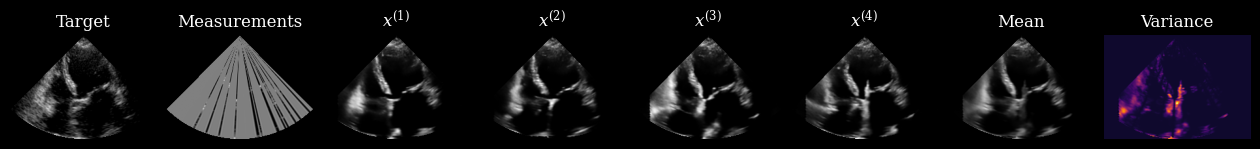

In [ ]:
# plot moments of the posterior
fig, ims = plot_image_grid(
    [
        data_sc[0],
        measurements_sc[0],
        posterior_samples_sc[0],
        posterior_samples_sc[1],
        posterior_samples_sc[2],
        posterior_samples_sc[3],
        posterior_mean_sc[0],
        variances_sc[0],
    ],
    titles=["Target", "Measurements", r"$x^{(1)}$", r"$x^{(2)}$", r"$x^{(3)}$", r"$x^{(4)}$", "Mean", "Variance"],
    ncols=8,
    vmin=-1,
    vmax=1,
    cmap=["gray"] * 7 + ["inferno"],
    # figsize=(12, 3),
)

### A simple action selection function

In [ ]:
from zea.agent.selection import GreedyEntropy
from zea.agent import masks

class GreedyVariance(GreedyEntropy):
    """
    Greedily select the lines with maximum variance.
    """

    def __init__(
        self,
        n_actions: int,
        n_possible_actions: int,
        img_width: int,
        img_height: int,
        mean: float = 0,
        std_dev: float = 1,
        num_lines_to_update: int = 5,
    ):
        super().__init__(
            n_actions,
            n_possible_actions,
            img_width,
            img_height,
            mean,
            std_dev,
            num_lines_to_update,
        )

    def sample(self, particles):
        """Sample the action using the greedy variance method.

        Args:
            particles (Tensor): Particles of shape (batch_size, n_particles, height, width)

        Returns:
            Tuple[Tensor, Tensor]:
                - Newly selected lines as k-hot vectors, shaped (batch_size, n_possible_actions)
                - Masks of shape (batch_size, img_height, img_width)
        """
        pixelwise_variance = ops.var(particles, axis=1)  # [batch_size, height, width]
        # we sum across the variances in each line to get a measure of line-wise uncertainty
        linewise_variance = ops.sum(pixelwise_variance, axis=1)  # [batch_size, width]

        # Greedily select best line, reweight entropies, and repeat
        all_selected_lines = []
        for _ in range(self.n_actions):
            max_contribution_line, linewise_variance = ops.vectorized_map(
                self.select_line_and_reweight_entropy, linewise_variance
            )
            all_selected_lines.append(max_contribution_line)

        selected_lines_k_hot = ops.any(
            ops.one_hot(
                all_selected_lines, self.n_possible_actions, dtype=masks._DEFAULT_DTYPE
            ),
            axis=0,
        )
        return selected_lines_k_hot, self.lines_to_im_size(selected_lines_k_hot)

In [ ]:
def belief_distribution_to_reconstruction(belief_distribution):
  """
  Args:
    belief_distribution: Tensor of shape (batch, n_particles, height, width)
  Returns:
    reconstruction: Tensor of shape (batch, height, width)
  """
  return belief_distribution[:, 0, ...] # selects the first posterior sample for each frame

In [ ]:
def run_perception_action_loop(data, action_selector):
  # select the first actions based on the prior samples
  prior_samples_batched = prior_samples[None, ..., 0]  # add batch, remove channel
  selected_lines, measurement_mask = action_selector.sample(prior_samples_batched)
  # initialise the previous samples as the prior samples
  previous_samples = prior_samples

  belief_distributions = []
  measurements = []
  for target_frame in tqdm(data):
      # perception
      measurements_t, measurement_mask_t = simulate_acquisition(target_frame, measurement_mask)
      posterior_samples = model.posterior_sample(
          measurements=measurements_t[..., None],  # add channel dim
          mask=measurement_mask_t[..., None],  # add channel dim
          initial_samples=previous_samples,
          n_samples=n_conditional_samples,
          n_steps=n_conditional_steps,
          omega=10,
          initial_step=n_initial_conditonal_steps,
      )

      # action
      selected_lines, measurement_mask = action_selector.sample(posterior_samples[..., 0])

      # gather the selected measurements and reconstructions for visualization
      belief_distributions.append(posterior_samples[0]) # we take [0] because batch_size=1
      measurements.append(measurements_t)
      # reset the previous_samples
      previous_samples = posterior_samples

  return ops.convert_to_tensor(belief_distributions), ops.convert_to_tensor(measurements)

In [ ]:
# initialize the action selector
frame_height, frame_width, _ = model.input_shape
greedy_entropy_action_selector = GreedyVariance(
    n_actions=14,  # acquire 25% of measurements
    n_possible_actions=frame_width,
    img_width=frame_width,
    img_height=frame_height,
)

# run the perception action loop
belief_distributions, measurements = run_perception_action_loop(data, greedy_entropy_action_selector)

100%|██████████| 15/15 [07:09<00:00, 28.61s/it]


In [ ]:
reconstructions = belief_distribution_to_reconstruction(belief_distributions)
reconstructions_sc = scan_convert(data=reconstructions[..., 0], **parameters)["data"]
measurements_sc = scan_convert(data=measurements[:, 0, ...], **parameters)["data"]
variances_sc = scan_convert(
    data=ops.var(belief_distributions, axis=1)[..., 0], **(parameters | {"fill_value": 0.0})
)["data"]
variances_sc = translate(variances_sc, range_to=(-1, 1))

## Visualize the results
Finally, we visualize our reconstructed sequence, along with the selected measurements and posterior variance at each step. The agent's goal of minizing posterior entropy is reflected in the low posterior variance throughout the sequence. You can see that the agent is quickly able to reduce the uncertainty after the first frame, when it was able to observe using acquisition of the first focused lines.

In [ ]:
# plot image
fig, ims = plot_image_grid(
    [data_sc[0], measurements_sc[0], reconstructions_sc[0], variances_sc[0]],
    titles=["Target", "Measurements", "Reconstruction", "Variance"],
    ncols=4,
    vmin=-1,
    vmax=1,
    cmap=["gray"] * 3 + ["inferno"],
    figsize=(11, 4),
)


def update(frame):
    ims[0].set_array(data_sc[frame])
    ims[1].set_array(measurements_sc[frame])
    ims[2].set_array(reconstructions_sc[frame])
    ims[3].set_array(variances_sc[frame])

    return ims


ani = animation.FuncAnimation(fig, update, frames=len(data_sc), blit=True, interval=100)
plt.close(fig)
HTML(ani.to_jshtml())

## Evaluate the model's performance
We use PSNR to evaluate reconstruction accuracy on 4 ultrasound videos.
Can you improve the score by implementing a new version of `action_selector` or `belief_distribution_to_reconstruction`?

In [ ]:
from zea import metrics
from tabulate import tabulate
from zea.models.lpips import LPIPS

lpips_model = LPIPS.from_preset("lpips")

config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vgg/vgg.weights.h5:   0%|          | 0.00/58.9M [00:00<?, ?B/s]

lin/lin.weights.h5:   0%|          | 0.00/39.0k [00:00<?, ?B/s]

In [ ]:
psnr_values = []
lpips_values = []

for i, sample in enumerate(dataset):
    print(f"{i+1}/{len(dataset)}")
    sample = preprocess(sample)
    belief_distributions, measurements = run_perception_action_loop(sample, greedy_entropy_action_selector)
    reconstructions = ops.clip(belief_distribution_to_reconstruction(belief_distributions)[..., 0], -1, 1) # strip channel dim for metrics
    reconstruction_psnr = metrics.psnr(reconstructions, sample)
    # convert to grayscale rgb for lpips
    reconstructions_rgb = ops.repeat(reconstructions[..., None], 3, axis=-1)
    sample_rgb = ops.repeat(sample[..., None], 3, axis=-1)
    reconstruction_lpips = lpips_model((reconstructions_rgb, sample_rgb)) # lpips requires channel dim
    psnr_values.append(reconstruction_psnr)
    lpips_values.append(ops.mean(reconstruction_lpips)) # take the mean across frames

# Prepare table
table_data = [
    ["Metric", "Mean", "Std Dev"],
    ["PSNR (↑)", f"{ops.mean(psnr_values):.2f}", f"{ops.std(psnr_values):.2f}"],
    ["LPIPS (↓)", f"{ops.mean(lpips_values):.2f}", f"{ops.std(lpips_values):.2f}"],
]

print("\n")
print(tabulate(table_data, headers="firstrow", tablefmt="fancy_grid"))

1/4


100%|██████████| 15/15 [06:55<00:00, 27.73s/it]


2/4


100%|██████████| 17/17 [08:02<00:00, 28.39s/it]


3/4


100%|██████████| 14/14 [06:27<00:00, 27.68s/it]


4/4


100%|██████████| 19/19 [08:48<00:00, 27.81s/it]




╒═══════════╤════════╤═══════════╕
│ Metric    │   Mean │   Std Dev │
╞═══════════╪════════╪═══════════╡
│ PSNR (↑)  │  22.32 │      0.9  │
├───────────┼────────┼───────────┤
│ LPIPS (↓) │   0.34 │      0.03 │
╘═══════════╧════════╧═══════════╛
